<a href="https://colab.research.google.com/github/kostya63/aton/blob/main/aton_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from google.colab import drive

In [ ]:
#Здесь используется ссылка на google drive, где лежат данные. Замените на актуальные значения для Вашего окружения!
drive.mount('/content/drive')
df_clients_data = pd.read_json('/content/drive/MyDrive/my_projects/aton/data/clients_data.json')
df_transactions_data = pd.read_excel('/content/drive/MyDrive/my_projects/aton/data/transactions_data.xlsx')

Mounted at /content/drive


In [ ]:
#Исследуем данные, в том числе на выбросы в числовых колонках - выбросов (явно нереальных значений) нет
print(df_clients_data.isnull().sum())
print(df_clients_data.info())
print(df_clients_data.head())
df_clients_data.describe()

id              1
age           983
gender       3319
net_worth     475
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9798 non-null   object 
 1   age        8816 non-null   float64
 2   gender     6480 non-null   object 
 3   net_worth  9324 non-null   float64
dtypes: float64(2), object(2)
memory usage: 306.3+ KB
None
                                     id   age   gender   net_worth
0  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7  41.0  Мужчина  2514729.46
1  c940f45c-d29b-439a-8fa3-f75018cef528  28.0  Мужчина   566568.29
2  cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c  55.0  Женщина  1896001.28
3                                  None  38.0  Женщина  4538759.60
4  3f43d7bc-37f0-4535-8391-51702d6ff81e  31.0  Мужчина  4865849.92


,age,net_worth
count,8816.000000,9.324000e+03
mean,40.052291,2.501561e+06
std,11.823810,1.430787e+06
min,20.000000,1.021397e+04
25%,30.000000,1.263024e+06
50%,40.000000,2.488230e+06
75%,50.000000,3.727101e+06
max,60.000000,4.999428e+06


In [ ]:
# Исследуем значения в колонках с перечислимыми значениями
print(df_clients_data['gender'].unique())

['Мужчина' 'Женщина' None]


In [ ]:
#Убираем дубликаты
df_clean_clients_data = df_clients_data.drop_duplicates()

# Исходя из требуемой аналитки для файла clients_data нужно решить удалять или оставлять строки с пустыми значениями:
# - id важно для соединения с таблицей transactions_data -> убираем строки
# - age важно для построения графика зависимости средней суммы транзакции от возраста клиентов, но не участвует в других аналитиках -> оставляем строки
# - gender не несет смысловой нагрузки в требуемой аналитике -> оставляем строки
# - net_worth важно для анализа по уровням активов, но не участвует в других аналитиках -> оставляем строки
df_clean_clients_data = df_clean_clients_data.dropna(subset=['id'])


In [ ]:
# Исследуем данные, в том числе на выбросы по числовым колонкам
print(df_transactions_data.isnull().sum())
print(df_transactions_data.info())
print(df_transactions_data.head())
df_transactions_data.describe()

transaction_id      474
client_id           202
transaction_date      0
service               0
amount              460
payment_method        0
city                  0
consultant            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9526 non-null   object 
 1   client_id         9798 non-null   object 
 2   transaction_date  10000 non-null  object 
 3   service           10000 non-null  object 
 4   amount            9540 non-null   float64
 5   payment_method    10000 non-null  object 
 6   city              10000 non-null  object 
 7   consultant        10000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 625.1+ KB
None
                         transaction_id                             client_id  \
0  ff36597c-df41-44a0-9f46-6aa1fe615270  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7 

,amount
count,9540.000000
mean,49246.781517
std,37961.999532
min,14.044907
25%,19074.838850
50%,41651.706800
75%,71378.894526
max,277442.155248


In [ ]:
#Убираем дубликаты
df_clean_transactions_data = df_transactions_data.drop_duplicates()

# Исходя из требуемой аналитки для файла transactions_data нужно решить удалять или оставлять строки с пустыми значениями:
# - transaction_id предположительно не участвует в аналитике, с другой стороны - это явно первичный ключ и записи без ПК вызывают сомнения в достовернсти -> посмотрим, что будет после очисток
# - client_id для аналитики по данным транзакций не важно -> оставляем строки
# - amount - критично для всех аналитик -> очищаем
df_clean_transactions_data = df_clean_transactions_data.dropna(subset=['amount'])
print(df_clean_transactions_data.isnull().sum())

transaction_id      451
client_id           189
transaction_date      0
service               0
amount                0
payment_method        0
city                  0
consultant            0
dtype: int64


In [ ]:
#Поля city, service и payment_type не содержат пустых значений, однако по смыслу - это перечислимый тип данных. Проверим, что в этих столбцах
unique_cities = df_clean_transactions_data['city'].unique()
print(unique_cities)

unique_services = df_clean_transactions_data['service'].unique()
print(unique_services)

unique_payment_methods = df_clean_transactions_data['payment_method'].unique()
print(unique_payment_methods)

['North Patrickport' 'New Zacharyport' 'Port Michellemouth' 'Erichaven'
 'Bondstad' 'West Jaymouth' 'Johnsonfort' 'Tonystad' 'Ronaldville'
 'Elizabethmouth' 'Ibarramouth' 'Matthewsville' 'North Lauriebury'
 'Lake Sallychester' 'Jeanettetown' 'Trevinoberg' 'South Andrew'
 'New Ryan' 'Hamiltontown' 'Davidmouth' 'Davidsonborough'
 'New Dianechester' 'Lake Arielmouth' 'Cruzport' 'Lake Tina' 'Krystalland'
 'Aprilstad' 'South Thomas' 'North Hannahmouth' 'Неизвестный город'
 'West Meredithhaven' 'North Melissaland' 'East Melissaville' 'Patelbury'
 'Michellehaven' 'Mayoberg' 'Harrisberg' 'Roberttown' 'Dannyburgh'
 'Port Jordan' 'North Emily' 'New Chelseaberg' 'New Tommyborough'
 'Port James' 'East Matthewmouth' 'East Jamie' 'Karenville' 'Kaneburgh'
 'Mirandaside' 'East Rachelmouth' 'Port Darlene']
['Структурирование капитала' 'Финансовое планирование'
 'Инвестиционное консультирование' 'Неизвестная услуга'
 'Налоговое планирование' 'Управление активами']
['Банковский перевод' 'Неизвестно' 'Кре

In [ ]:
# Для универсального обращения с данными заменим значения вида "Неизвестный ..." на NaN
df_clean_transactions_data['service'] = df_clean_transactions_data['service'].replace('Неизвестная услуга', np.nan)
df_clean_transactions_data['payment_method'] = df_clean_transactions_data['payment_method'].replace('Неизвестно', np.nan)
df_clean_transactions_data['city'] = df_clean_transactions_data['city'].replace('Неизвестный город', np.nan)

In [ ]:
# В дальнейшем планируется делать анализ отдельно по  услугам, способу платежа и городу. Следовательно, строки, где все три поля не определены, для анализа нам бесполезны
df_transactions_data.query("service.isna() and payment_method.isna() and city.isna()").info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    0 non-null      object 
 1   client_id         0 non-null      object 
 2   transaction_date  0 non-null      object 
 3   service           0 non-null      object 
 4   amount            0 non-null      float64
 5   payment_method    0 non-null      object 
 6   city              0 non-null      object 
 7   consultant        0 non-null      object 
dtypes: float64(1), object(7)
memory usage: 0.0+ bytes


In [ ]:
df_clean_transactions_data = df_clean_transactions_data.query("not (service.isna() and payment_method.isna() and city.isna())")

In [ ]:
#Вернемся к записям с пустым transaction_id, записи без первичного ключа выглядят подозрительно.
print(df_clean_transactions_data.isnull().sum())

transaction_id      451
client_id           189
transaction_date      0
service             947
amount                0
payment_method      964
city                368
consultant            0
dtype: int64


In [ ]:
#Их число - порядка 5% и ими можно пренебречь
#Однако, для полной строгости посмотрим, может быть там какие-то выдающиеся платежи?
invalid_transactions = df_clean_transactions_data.query("transaction_id.isna()")
print(df_clean_transactions_data.describe())
print(invalid_transactions.describe())


              amount
count    9539.000000
mean    49251.646360
std     37961.015481
min        14.044907
25%     19077.540961
50%     41655.855132
75%     71379.488617
max    277442.155248
              amount
count     451.000000
mean    44328.508103
std     34380.601454
min       200.399626
25%     14947.405215
50%     36864.777325
75%     63607.929001
max    167055.708253


In [ ]:
#Как видим, записи с пустым transaction_id ничем не выделяются, поэтому удаляем
df_clean_transactions_data = df_clean_transactions_data.dropna(subset=['transaction_id'])

In [ ]:
#Приводим к типу datetime и нормализуем поле transaction_date, если преобразовать не удается - пишем значение NaT
df_clean_transactions_data['transaction_date'] = pd.to_datetime(df_clean_transactions_data['transaction_date'], errors='coerce')
df_clean_transactions_data['norm_transaction_date'] = df_clean_transactions_data['transaction_date'].dt.normalize()

In [ ]:
#Смотрим, есть ли записи с пустой датой транзакции
print(len(df_clean_transactions_data))
print(df_clean_transactions_data.isnull().sum())

9088
transaction_id             0
client_id                180
transaction_date         917
service                  897
amount                     0
payment_method           912
city                     359
consultant                 0
norm_transaction_date    917
dtype: int64


In [ ]:
# 2.1 Определить топ-5 наиболее популярных услуг по количеству заказов
top_services = df_clean_transactions_data.query("not service.isna()")['service'].value_counts().sort_values(ascending=False)
print(top_services.head(5))

service
Инвестиционное консультирование    2215
Управление активами                1823
Финансовое планирование            1391
Налоговое планирование             1391
Структурирование капитала          1371
Name: count, dtype: int64


In [ ]:
# 2.2 Рассчитать среднюю сумму транзакций по каждому городу
df_clean_transactions_by_city = df_clean_transactions_data.query("not (city == 'Неизвестный город')")
avg = df_clean_transactions_by_city.query("not city.isna()").groupby('city')['amount'].mean().reset_index().sort_values(by='amount', ascending=False)
with pd.option_context('display.float_format', '{:,.2f}'.format):
  print(avg)

                  city    amount
41  Port Michellemouth 56,208.90
25       Michellehaven 55,655.76
30    New Tommyborough 55,289.24
9     East Rachelmouth 55,149.59
13          Harrisberg 53,340.32
34    North Lauriebury 53,100.57
47         Trevinoberg 52,894.83
35   North Melissaland 52,800.68
31     New Zacharyport 52,598.51
17           Kaneburgh 52,488.02
16         Johnsonfort 52,126.08
1             Bondstad 52,071.69
22           Lake Tina 52,020.96
49  West Meredithhaven 51,723.69
44        South Andrew 51,628.96
19         Krystalland 51,383.98
20     Lake Arielmouth 51,352.54
32         North Emily 50,876.20
37           Patelbury 50,786.68
5      Davidsonborough 50,201.62
12        Hamiltontown 50,074.19
43         Ronaldville 49,695.50
0            Aprilstad 49,602.16
24            Mayoberg 49,465.83
11           Erichaven 49,408.47
33   North Hannahmouth 49,396.42
27     New Chelseaberg 49,213.13
40         Port Jordan 48,920.13
46            Tonystad 48,575.35
7    East 

In [ ]:
#2.3 Определить услугу с наибольшей выручкой (по сумме amount)
top_services_by_amount = df_clean_transactions_data.query("not service.isna() and amount > 0").groupby('service')['amount'].sum().sort_values(ascending=False)

with pd.option_context('display.float_format', '{:,.2f}'.format):
    print(top_services_by_amount)

top_service = top_services_by_amount.idxmax()
top_revenue = top_services_by_amount.max()

print(" ")

print(f"Услуга с наибольшей выручкой: {top_service:}")
print(f"Общая выручка по этой услуге: {top_revenue:,.2f}")

service
Инвестиционное консультирование   110,321,843.28
Управление активами                89,652,637.67
Финансовое планирование            69,400,197.01
Налоговое планирование             68,726,791.36
Структурирование капитала          65,971,025.35
Name: amount, dtype: float64
 
Услуга с наибольшей выручкой: Инвестиционное консультирование
Общая выручка по этой услуге: 110,321,843.28


In [ ]:
#2.4 Вычислить процент транзакций по способам оплаты
counts = df_clean_transactions_data.query("not payment_method.isna()").groupby('payment_method')['payment_method'].count().sort_values(ascending=False)

# Общее количество транзакций
total = len(df_clean_transactions_data.query("not payment_method.isna()"))

# Проценты
percent = (counts / total) * 100
with pd.option_context('display.float_format', '{:,.2f}'.format):
  print(percent)

payment_method
Кредитная карта      44.47
Банковский перевод   38.53
Наличные             10.98
Криптовалюта          6.02
Name: payment_method, dtype: float64


In [ ]:
#2.5 Рассчитать выручку за последний месяц (по сумме amount). Делаем предположение, что "последний месяц" = "30 дней в прошлое от максимальной даты платежа"
max_date = df_clean_transactions_data['norm_transaction_date'].max()
start_date = max_date - pd.DateOffset(days=30)
revenue_last_30 = df_clean_transactions_data.query("norm_transaction_date >= @start_date")['amount'].sum()
print(f"Выручка за последние 30 дней (с {start_date.date()} по {max_date.date()}): {revenue_last_30:,.2f}")


Выручка за последние 30 дней (с 2025-02-18 по 2025-03-20): 157,186,927.17


In [ ]:
#3.1 Провести анализ по уровням активов и определить, какие категории клиентов приносят наибольшую выручку.
df_merged_transactions_data = df_clean_transactions_data.merge(df_clean_clients_data[['id', 'net_worth']], left_on='client_id', right_on='id', how='right')
revenue_1 = df_merged_transactions_data.query("net_worth < 100000")['amount'].sum()
revenue_2 = df_merged_transactions_data.query("net_worth >= 100000 and net_worth <= 1000000")['amount'].sum()
revenue_3 = df_merged_transactions_data.query("net_worth > 1000000")['amount'].sum()

print(f"Выручка по клиентам с net_worth < 100,000:              {revenue_1:,.2f}")
print(f"Выручка по клиентам с 100,000 <= net_worth < 1,000,000: {revenue_2:,.2f}")
print(f"Выручка по клиентам с net_worth >= 1,000,000:           {revenue_3:,.2f}")


Выручка по клиентам с net_worth < 100,000:              7,568,605.37
Выручка по клиентам с 100,000 <= net_worth < 1,000,000: 72,154,625.32
Выручка по клиентам с net_worth >= 1,000,000:           339,160,847.61


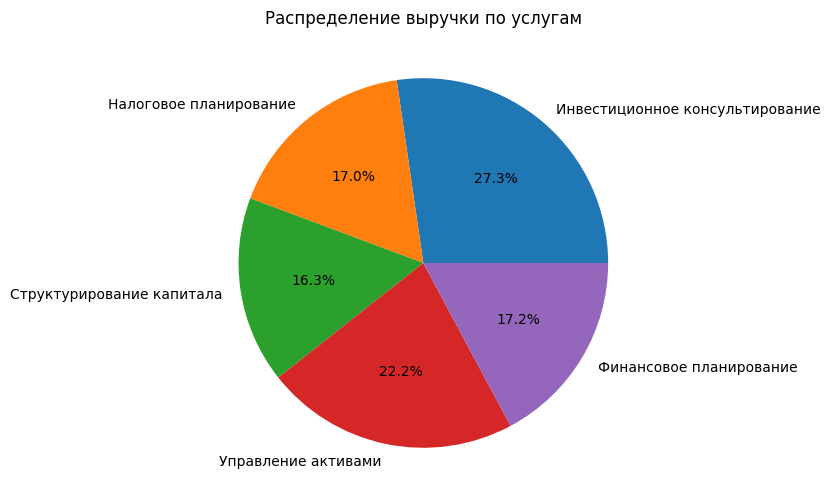

In [ ]:
# 4.1 Создать диаграмму выручки по услугам.
service_sum = df_clean_transactions_data.groupby('service')['amount'].sum()

service_sum.plot.pie(autopct='%1.1f%%', figsize=(6, 6))
plt.title('Распределение выручки по услугам')
plt.ylabel('')
plt.show()

/tmp/ipykernel_196/2178295046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_clients_data_by_age['age'] = df_clean_clients_data_by_age['age'].astype(int)


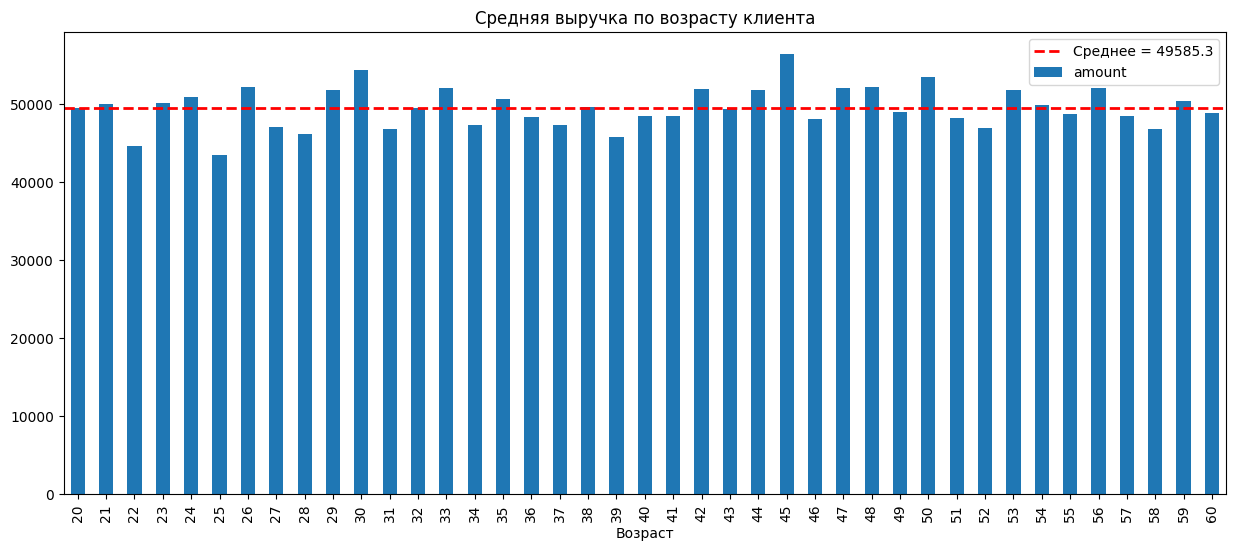

In [ ]:
#4.2 Построить график зависимости средней суммы транзакции от возраста клиентов
df_clean_clients_data_by_age = df_clean_clients_data.dropna(subset=['age'])
df_clean_clients_data_by_age['age'] = df_clean_clients_data_by_age['age'].astype(int)
age_sum = df_clean_transactions_data.merge(df_clean_clients_data_by_age[['id', 'age']], left_on='client_id', right_on='id', how='right').groupby('age')['amount'].mean()

mean_val = age_sum.mean()

ax = age_sum.plot.bar(figsize=(15, 6))

ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_val:.1f}')
ax.legend()

plt.title('Средняя выручка по возрасту клиента')
plt.ylabel('')
plt.xlabel('Возраст')
plt.show()

In [ ]:
# 5.Прогнозирование. Прогнозирование спроса на следующий месяц (например, с использованием линейной регрессии).
min_transaction_date = df_clean_transactions_data['norm_transaction_date'].min()
max_transaction_date = df_clean_transactions_data['norm_transaction_date'].max()
print(min_transaction_date)
print(max_transaction_date)

2025-01-01 00:00:00
2025-03-20 00:00:00


In [ ]:
# Видим, что у нас есть данные за три неполных месяца, поэтому месячный сезонный фактор учесть невозможно.
# Однако, возможна зависимость от дня недели
# Для последующей оценки предсказаний возьмем среднее значение amount за последние 30 дней

threshold = max_transaction_date - pd.Timedelta(days=30)
simple_prediction = df_clean_transactions_data.query("not norm_transaction_date.isna() and norm_transaction_date >= @threshold")['amount'].mean()
print(simple_prediction)

49321.28244950977


In [ ]:
# Агрегируем amount по дням
daily = df_clean_transactions_data.query("not norm_transaction_date.isna()").groupby(df_clean_transactions_data['norm_transaction_date'])['amount'].mean().reset_index()
daily.columns = ['ds', 'y']  # Prophet требует столбцы ds (дата) и y (значение)

#daily = daily.sort_values('ds')
#print(daily.head(5))

Прогноз на ближайшие 30 дней:
            ds          yhat    yhat_lower    yhat_upper
78  2025-03-20  49119.080502  44380.462267  53731.208583
79  2025-03-21  50235.718010  45657.781785  54816.968371
80  2025-03-22  48327.227798  43780.893305  52812.067985
81  2025-03-23  48604.199082  43948.867501  53356.913661
82  2025-03-24  51033.556205  46522.785146  56089.003573
83  2025-03-25  48538.623288  44224.310287  52995.903983
84  2025-03-26  50536.093890  46142.805460  55271.082242
85  2025-03-27  49182.015506  44506.454078  53582.603579
86  2025-03-28  50298.653015  45730.137525  54926.595467
87  2025-03-29  48390.162803  44187.102110  52920.711954
88  2025-03-30  48667.134087  43841.649067  53198.046014
89  2025-03-31  51096.491209  46455.274916  55971.325541
90  2025-04-01  48601.558293  44183.800250  52891.813637
91  2025-04-02  50599.028894  45720.077731  54879.150808
92  2025-04-03  49244.950511  44614.362866  53648.066905
93  2025-04-04  50361.588019  45709.283777  54899.485665
9

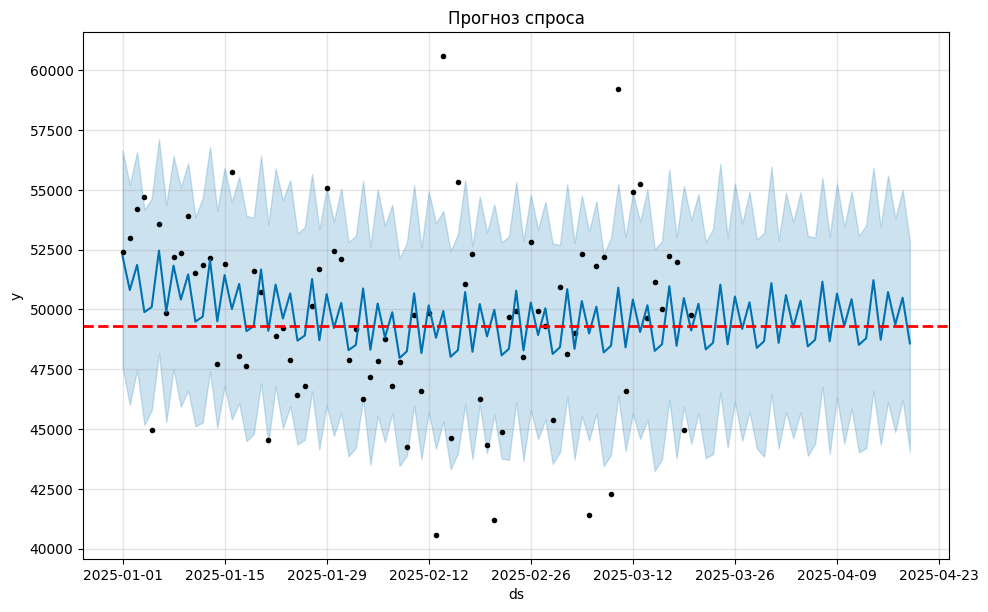

In [ ]:
# Создаём модель
model = Prophet(yearly_seasonality=False,  # данных меньше года, отключаем годовую сезонность
                weekly_seasonality=True,   # недельная сезонность может быть
                daily_seasonality=False)   # дневная не нужна
model.fit(daily)

# Создаём датафрейм с будущими датами на 30 дней
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Прогноз на апрель (последние 30 строк)
april_forecast_prophet = forecast[forecast['ds'] >= max_transaction_date]
print("Прогноз на ближайшие 30 дней:")
print(april_forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# Визуализация
fig = model.plot(forecast)
plt.axhline(y=simple_prediction, color='red', linestyle='--', linewidth=2, label=f'Среднее = {mean_val:.1f}')
ax.legend()
plt.title('Прогноз спроса')
plt.show()

In [ ]:
# Агрегация по дням
daily = df_clean_transactions_data.query("not norm_transaction_date.isna()").groupby(df_clean_transactions_data['norm_transaction_date'])['amount'].mean().reset_index()
daily.columns = ['ds', 'total_amount']
daily = daily.sort_values('ds')

# Создание признаков
# Номер дня от начала наблюдений (для линейного тренда)
daily['day_num'] = range(len(daily))
# День недели: 0 = понедельник, 6 = воскресенье
daily['day_of_week'] = daily['ds'].dt.dayofweek
# Признак выходного дня (суббота, воскресенье)
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

# Формирование матрицы признаков и целевой переменной
features = ['day_num', 'day_of_week', 'is_weekend']
X = daily[features]
y = daily['total_amount']

# Создание пайплайна с кодированием категориального признака day_of_week
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['day_num', 'is_weekend']),
        ('cat', OneHotEncoder(drop='first'), ['day_of_week'])
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Обучение на всех имеющихся данных
model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['day_num', 'is_weekend']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['day_of_week'])])),
                ('regressor', LinearRegression())])

In [ ]:
# Подготовка данных для апреля 2025
april_dates = pd.date_range(start=max_transaction_date, end=max_transaction_date+pd.Timedelta(days=30))
april_df = pd.DataFrame({'ds': april_dates})
april_df['day_num'] = (april_df['ds'] - daily['ds'].min()).dt.days
april_df['day_of_week'] = april_df['ds'].dt.dayofweek
april_df['is_weekend'] = (april_df['day_of_week'] >= 5).astype(int)

X_april = april_df[features]

# Строим прогноз
pred_april_lin = model.predict(X_april)


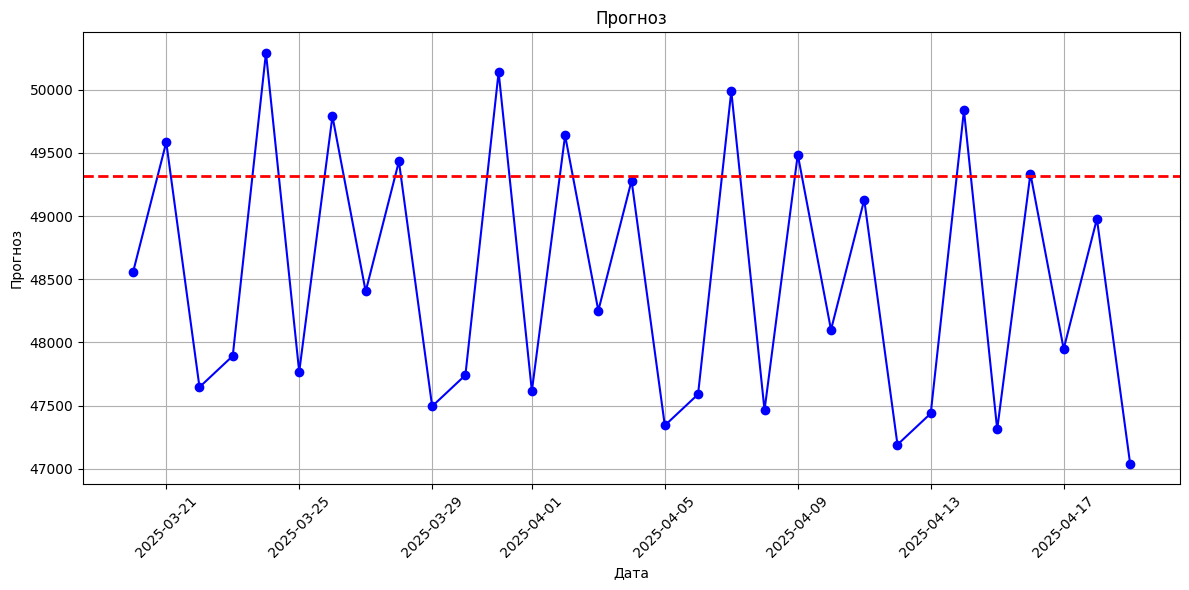

In [ ]:
april_forecast_lin = pd.DataFrame({'ds': april_dates, 'y_lin': pred_april_lin})

plt.figure(figsize=(12, 6))
plt.plot(april_forecast_lin['ds'], april_forecast_lin['y_lin'], marker='o', linestyle='-', color='b')
plt.axhline(y=simple_prediction, color='red', linestyle='--', linewidth=2, label=f'Простой прогноз = {mean_val:.1f}')
plt.title('Прогноз')
plt.xlabel('Дата')
plt.ylabel('Прогноз')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

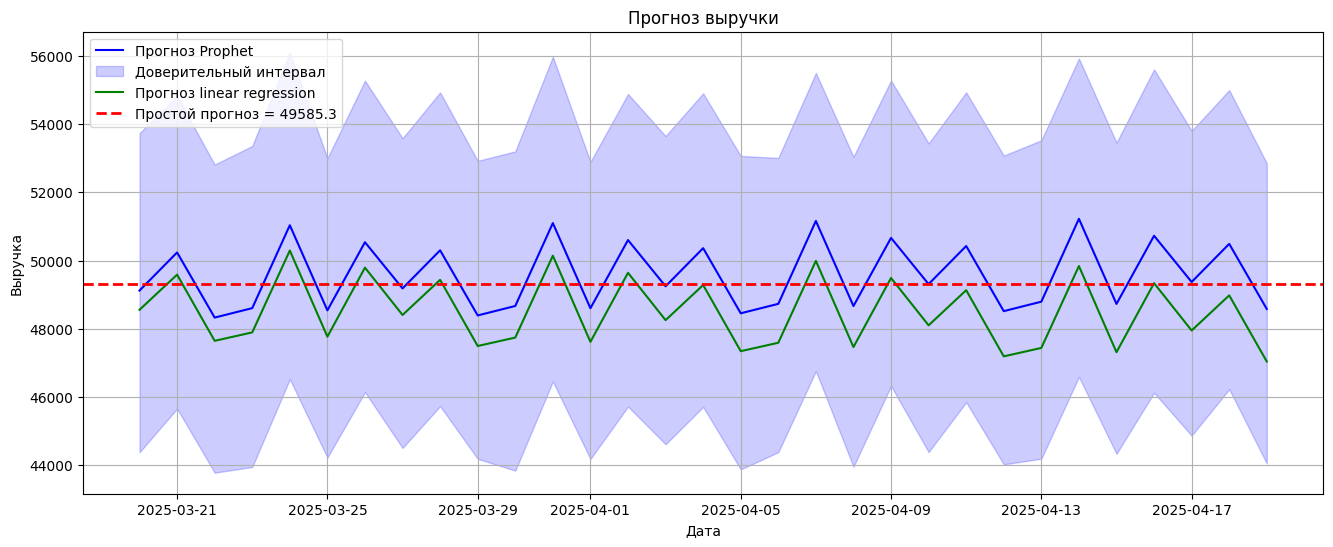

In [ ]:
# Три прогноза по выручке на одном графике
plt.figure(figsize=(16,6))
plt.plot(april_forecast_prophet['ds'], april_forecast_prophet['yhat'], label='Прогноз Prophet', color='blue')
plt.fill_between(april_forecast_prophet['ds'], april_forecast_prophet['yhat_lower'], april_forecast_prophet['yhat_upper'], color='blue', alpha=0.2, label='Доверительный интервал')
plt.plot(april_forecast_lin['ds'], april_forecast_lin['y_lin'], label = 'Прогноз linear regression', color='green')
plt.axhline(y=simple_prediction, color='red', linestyle='--', linewidth=2, label=f'Простой прогноз = {mean_val:.1f}')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.title('Прогноз выручки')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Суммарный прогноз
print(f"Суммарный прогноз (Prophet) на 30 дней: {april_forecast_prophet['yhat'].sum():,.2f}")
print(f"Суммарный прогноз (усреднение) на 30 дней: {simple_prediction*30:,.2f}")
print(f"Суммарный прогноз (линейная регрессия) на 30 дней: {pred_april_lin.sum():,.2f}")

Суммарный прогноз (Prophet) на 30 дней: 1,536,658.51
Суммарный прогноз (усреднение) на 30 дней: 1,479,638.47
Суммарный прогноз (линейная регрессия) на 30 дней: 1,503,714.40
